# # Multi-class classification
### Putting it all together with a multi-classification problem.
* * * ### 2`Comparision between binary-classification VS Multi-class classification.`*
* * Binary-classification = one thing or another(cat vs. dog, spam vs. non-spam)
* * Multi-class classification = more than one than or another (cat vs. dog vs. chicken)

In [634]:
import torch as tr # type: ignore
import matplotlib.pyplot as plt # type: ignore
from sklearn.datasets import make_blobs  # type: ignore
from sklearn.model_selection import train_test_split  # type: ignore
from torch import nn # type: ignore
Num_calsses = 2
Num_Features = 4
Random_seed = 42


# 1. Create multi-class data
x_blob,y_blob = make_blobs(n_features=Num_Features,
                           centers=Num_Features,
                           cluster_std = 1.5,
                           random_state=Random_seed)


# 2. Turn data from numpy into tensor
x_blob = tr.from_numpy(x_blob).type(tr.float32)
y_blob = tr.from_numpy(y_blob).type(tr.LongTensor)

# 3. Split data into train and test model
x_train,x_test,y_train,y_test = train_test_split(x_blob,y_blob,test_size = 0.2, random_state=Random_seed)

In [635]:
len(x_train), len(x_test), len(y_train),len(y_test)

(80, 20, 80, 20)

In [636]:
x_train[:5], y_train[:5]

(tensor([[ -2.7511,   9.6204,   7.4692,   2.2350],
         [ -3.7680,   8.5505,   5.1368,   3.4365],
         [ -5.6931,  -8.2442,  -6.7341,   5.2207],
         [  5.4155,  -5.3877,  -5.9961,  -7.0923],
         [  0.6319,   4.0722, -14.4502,   7.8616]]),
 tensor([0, 0, 1, 3, 2]))

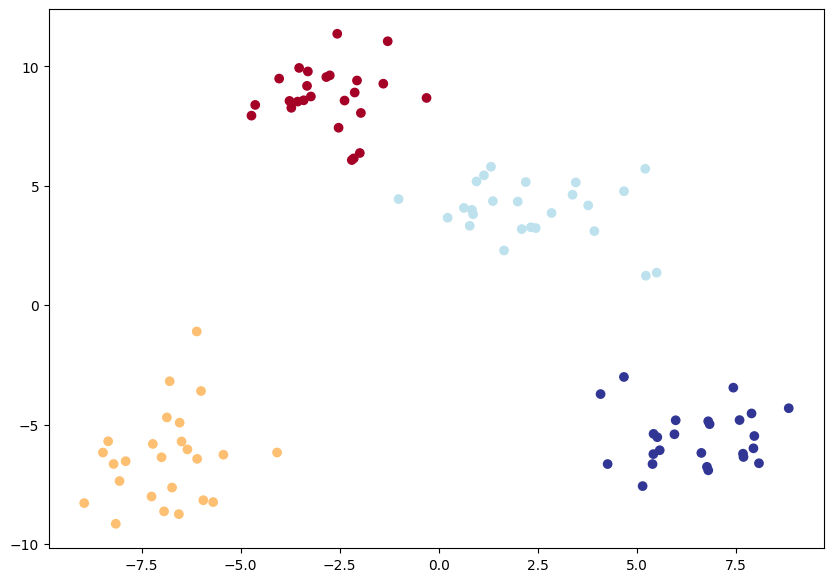

In [637]:
# 4. Visualized our data
plt.figure(figsize = (10,7))
plt.scatter(x_blob[:,0],x_blob[:,1],c= y_blob,cmap = plt.cm.RdYlBu)


* Buliding a multi-calss classification model in Pytorch

In [638]:
# Create device agnostic code
device = 'cuda' if tr.cuda.is_available() else 'cpu'
device = 'cuda' if tr.cuda.is_available() else 'cpu'
device

'cpu'

In [639]:
# Bulid a multi-class calssification

class BlobModel(nn.Module):
    def __init__(self,input_feature,output_feature,hidden_unit = 8):
        """_summary_

        Args:
            input_feature (_type_ = int ): The number of features to the model
            output_feature (_type_ = int): The number of outputs features
            hidden_unit (int, optional): The number of hidden units between layers, default 8
            returns 
            Example
        """
        
        super().__init__() 
        self.linear_stack_layer = nn.Sequential(
            nn.Linear(in_features = input_feature,out_features = hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features = hidden_unit,out_features = hidden_unit),
            nn.ReLU(), 
            nn.Linear(in_features = hidden_unit,out_features = output_feature)
        )
    def forward(self,x):
        return  self.linear_stack_layer(x)  
        

In [640]:
bm = BlobModel(input_feature = 4,output_feature =4, hidden_unit = 8).to(device)

In [641]:
bm

BlobModel(
  (linear_stack_layer): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [642]:
x_blob.shape, y_blob.shape

(torch.Size([100, 4]), torch.Size([100]))

In [643]:
x_blob[:5],y_blob[:5]

(tensor([[  6.7626,  -6.7690,  -4.9008,  -6.5525],
         [  4.0792,  -3.7224,  -6.5353,  -4.4752],
         [ -6.9953,  -6.3684,  -8.4233,   8.5643],
         [  5.2055,   5.7101, -11.8674,   8.6718],
         [ -6.0967,  -6.4346,  -8.4626,   7.8432]]),
 tensor([3, 3, 1, 2, 1]))

In [644]:
tr.unique(y_blob)

tensor([0, 1, 2, 3])

In [645]:
# Crea te a loss function for multi-class calssification 
loss_fn = nn.CrossEntropyLoss()
optimizer = tr.optim.SGD(params = bm.parameters(),lr = 0.001)

In [646]:
bm.eval()
with tr.inference_mode():
    
    y_pred = bm(x_test.to(device))
    
y_pred[:15]    

tensor([[-0.0523,  0.1891, -0.3580,  0.0229],
        [-0.7156, -0.8498,  0.2825, -0.9566],
        [-0.7387, -0.8880,  0.3360, -0.9775],
        [-0.6092, -0.7798,  0.2728, -0.8353],
        [-0.3451,  0.3624, -0.4026, -0.0800],
        [ 0.1099,  0.0409, -0.2706,  0.2647],
        [ 0.1029,  0.1200, -0.2435,  0.3245],
        [-0.5972, -0.8059,  0.2680, -0.7895],
        [-0.4276,  0.0928, -0.2287,  0.2531],
        [-0.6941, -0.8826,  0.3293, -0.9218],
        [-0.0401,  0.2342, -0.3001,  0.0559],
        [-0.1726,  0.2366, -0.3520,  0.0073],
        [-0.6480, -0.7639,  0.2848, -0.8880],
        [-0.3688,  0.3198, -0.0861, -0.1025],
        [-0.0624,  0.1014, -0.3754,  0.0215]])

In [647]:
y_test[:15]

tensor([0, 3, 3, 3, 0, 2, 2, 3, 0, 3, 0, 0, 3, 1, 0])

In [648]:
# Convert our model's logits output's tp prediction probabilities.
y_pred_probs =  tr.softmax(y_pred,dim = 1)
print(y_pred[:5])


tensor([[-0.0523,  0.1891, -0.3580,  0.0229],
        [-0.7156, -0.8498,  0.2825, -0.9566],
        [-0.7387, -0.8880,  0.3360, -0.9775],
        [-0.6092, -0.7798,  0.2728, -0.8353],
        [-0.3451,  0.3624, -0.4026, -0.0800]])


In [649]:
print(y_pred_probs[:5])

tensor([[0.2446, 0.3114, 0.1802, 0.2637],
        [0.1861, 0.1627, 0.5049, 0.1462],
        [0.1793, 0.1544, 0.5251, 0.1412],
        [0.1978, 0.1667, 0.4777, 0.1577],
        [0.1895, 0.3845, 0.1789, 0.2470]])


In [650]:
# Now we chech the result of out activation function.
tr.sum(y_pred_probs[0])

tensor(1.)

In [651]:
tr.max(y_pred_probs[0]),tr.min(y_pred_probs[0])

(tensor(0.3114), tensor(0.1802))

In [652]:
def accuracy(y_true,y_pred):
    correct = tr.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))
    return acc

In [653]:
# Convert our model's prediction probabilities to prediction labels
y_preds = tr.argmax(y_pred_probs,dim = 1)
y_preds

tensor([1, 2, 2, 2, 1, 3, 3, 2, 3, 2, 1, 1, 2, 1, 1, 1, 3, 3, 3, 1])

#### Create a training and testing loop for a multi-class PyTorch model


In [654]:
bm.eval()
tr.cuda.manual_seed(42)
epochs = 1000
x_blob_train, y_blob_train = x_train.to(device),y_train.to(device)
x_blob_test,y_blob_test = x_test.to(device),y_test.to(device)

for epoch in range(epochs):
    bm.train()
    y_logits = bm(x_train)
    y_preds = tr.softmax(y_logits,dim = 1).argmax(dim =1)
    loss= loss_fn(y_logits,y_blob_train)
  
    acc = accuracy(y_true = y_blob_train,y_pred = y_preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    bm.eval()
    with tr.inference_mode():
        logits_pred = bm(x_blob_test)
        test_pred = tr.softmax(logits_pred,dim = 1).argmax(dim=1)
        test_loss = loss_fn(logits_pred,y_blob_test)
        test_acc = accuracy(y_true = y_blob_test,y_pred = test_pred)
    if epoch %  100 == 0 :
        print(f"Epoch: {epoch} | Loss: {loss:.2f} | Test Loss: {test_loss:.2f} | Accuracy: {acc:.2f}% | Test Accuracy: {test_acc:.2f}% ")    
    

Epoch: 0 | Loss: 1.53 | Test Loss: 1.61 | Accuracy: 0.29% | Test Accuracy: 0.15% 
Epoch: 100 | Loss: 1.26 | Test Loss: 1.35 | Accuracy: 0.41% | Test Accuracy: 0.35% 
Epoch: 200 | Loss: 1.03 | Test Loss: 1.14 | Accuracy: 0.59% | Test Accuracy: 0.60% 
Epoch: 300 | Loss: 0.89 | Test Loss: 1.01 | Accuracy: 0.68% | Test Accuracy: 0.60% 
Epoch: 400 | Loss: 0.79 | Test Loss: 0.91 | Accuracy: 0.70% | Test Accuracy: 0.60% 
Epoch: 500 | Loss: 0.71 | Test Loss: 0.83 | Accuracy: 0.72% | Test Accuracy: 0.60% 
Epoch: 600 | Loss: 0.65 | Test Loss: 0.77 | Accuracy: 0.74% | Test Accuracy: 0.60% 
Epoch: 700 | Loss: 0.60 | Test Loss: 0.72 | Accuracy: 0.76% | Test Accuracy: 0.60% 
Epoch: 800 | Loss: 0.56 | Test Loss: 0.67 | Accuracy: 0.88% | Test Accuracy: 0.85% 
Epoch: 900 | Loss: 0.52 | Test Loss: 0.62 | Accuracy: 0.96% | Test Accuracy: 0.95% 


In [658]:
# Make prediction
bm.eval()
y_blob_test = y_blob_test.float()
with tr.inference_mode():
    y_logits = bm(x_blob_test)
y_logits[:10]    

tensor([[ 4.2440e-01, -4.0262e-01, -1.9656e-01, -1.0212e-01],
        [-1.0859e+00, -1.8508e+00,  3.8997e-01,  5.2101e-01],
        [-9.1475e-01, -1.5543e+00,  2.7295e-01,  4.8471e-01],
        [-6.4885e-01, -1.3220e+00,  2.0471e-01,  4.7662e-01],
        [ 2.9102e-01, -7.9621e-01, -1.2752e-03, -5.6701e-01],
        [-1.3684e+00, -3.0201e+00,  1.4444e+00, -5.1250e-01],
        [-1.2889e+00, -2.0543e+00,  1.2493e+00, -9.3532e-01],
        [-4.6721e-01, -1.0294e+00,  4.7054e-02,  2.5857e-01],
        [ 2.6930e-01, -7.1395e-01, -1.0681e-02, -2.7328e-01],
        [-6.9011e-01, -1.2928e+00,  1.6072e-01,  3.7264e-01]])

In [659]:
y_pred_probs = tr.softmax(y_logits,dim = 1)
y_pred_probs[:10]

tensor([[0.3898, 0.1705, 0.2095, 0.2302],
        [0.0924, 0.0430, 0.4040, 0.4606],
        [0.1129, 0.0595, 0.3701, 0.4574],
        [0.1441, 0.0735, 0.3383, 0.4441],
        [0.3988, 0.1344, 0.2977, 0.1691],
        [0.0495, 0.0095, 0.8245, 0.1165],
        [0.0643, 0.0299, 0.8142, 0.0916],
        [0.1884, 0.1074, 0.3150, 0.3892],
        [0.3688, 0.1380, 0.2788, 0.2144],
        [0.1474, 0.0807, 0.3452, 0.4267]])

In [660]:
y_blob_test

tensor([0., 3., 3., 3., 0., 2., 2., 3., 0., 3., 0., 0., 3., 1., 0., 1., 2., 2.,
        2., 1.])